In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv(r'C:/Users/mohdd/OneDrive/Documents/Desktop/Learning_Machine_Learning/FirstModel_Practice/student.csv')

df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       99 non-null     float64
 1   package    99 non-null     float64
 2   placement  99 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.4 KB


In [4]:
# check duplicate values
df.duplicated().sum()

df.drop_duplicates(inplace=True)
df.shape


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 98
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       98 non-null     float64
 1   package    98 non-null     float64
 2   placement  98 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 3.1 KB


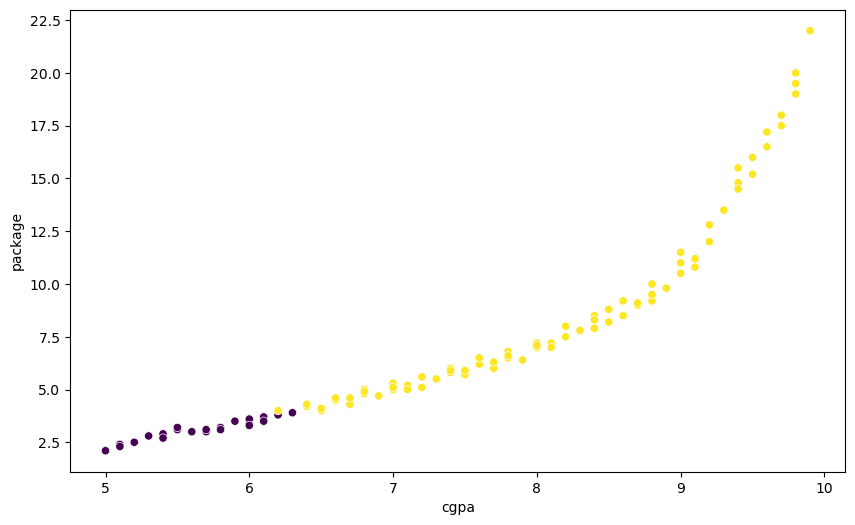

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df['cgpa'], y=df['package'], c=df['placement'], data=df)
plt.show()

In [6]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]



In [7]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=0)

# shape of train and test data
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(88, 2)
(10, 2)
(88,)
(10,)


In [8]:
# scaling

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [9]:
# using models import logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# import r2 and mse
from sklearn.metrics import r2_score, mean_squared_error

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_pred


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("R2 score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))



Accuracy: 1.0
R2 score: 1.0
MSE: 0.0


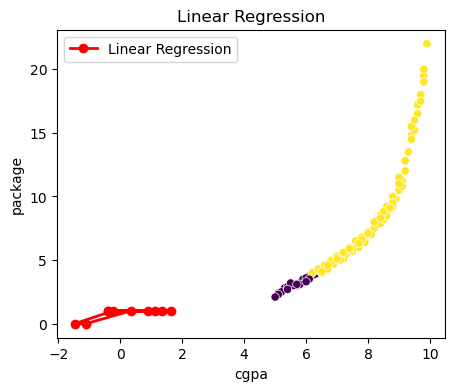

In [11]:
plt.figure(figsize=(5, 4))

sns.scatterplot(x=df['cgpa'], y=df['package'], c=df['placement'], data=df)

plt.plot(x_test[:, 0], y_pred, color='red', linewidth=2, label='Linear Regression', marker='o')

plt.title('Linear Regression')
plt.legend()
plt.show()




In [13]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
